## 1. Setup and Imports

# Update 2: Retrieval-Augmented Verification & Uncertainty Quantification
**CS 593 NLP Final Project — Purdue University, Spring 2026**

Authors: Varun Chundru, Debasmita Biswas

This notebook implements the Update 2 experiments:
1. **Retrieval-Augmented Verification** — Dense retrieval similarity as a detection signal (Proposal Phase 1)
2. **Uncertainty Quantification** — Monte Carlo Dropout for prediction uncertainty (Proposal Phase 2)
3. **Temperature Scaling** — Calibration / L_calibration from proposal (Proposal Phase 2)
4. **Cross-Dataset Evaluation on SciFact** — Domain-specific generalization with PubMedBERT retrieval (Proposal Phase 1)

**NOTE:** Phase 3 (DPO Fine-tuning) is deferred to Final Paper if time permits, as stated in the proposal.

**Environment:** Kaggle Notebook with GPU (T4x2)

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.64 GB


## 2. Load and Prepare HaluEval Dataset

**IMPORTANT:** This section reproduces the EXACT same data pipeline and splits
as notebook 01 (same seeds, same preprocessing, same split ratios) to ensure
the test set is identical. This allows direct comparison with Update 1 results.

In [2]:
print("Loading HaluEval _samples datasets...")
dataset_qa = load_dataset("pminervini/HaluEval", "qa_samples")
dataset_dialogue = load_dataset("pminervini/HaluEval", "dialogue_samples")
dataset_summarization = load_dataset("pminervini/HaluEval", "summarization_samples")

print(f"QA samples: {len(dataset_qa['data'])}")
print(f"Dialogue samples: {len(dataset_dialogue['data'])}")
print(f"Summarization samples: {len(dataset_summarization['data'])}")

Loading HaluEval _samples datasets...


README.md: 0.00B [00:00, ?B/s]

qa_samples/data-00000-of-00001.parquet:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

dialogue_samples/data-00000-of-00001.par(…):   0%|          | 0.00/2.83M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

summarization_samples/data-00000-of-0000(…):   0%|          | 0.00/25.5M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

QA samples: 10000
Dialogue samples: 10000
Summarization samples: 10000


In [3]:
# EXACT same preprocessing functions from notebook 01

def preprocess_qa_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['knowledge'])):
        knowledge = examples['knowledge'][i]
        question = examples['question'][i]
        answer = examples['answer'][i]
        hallucination = examples['hallucination'][i]
        context = f"Question: {question}\nKnowledge: {knowledge}"
        text = f"{context}\n\nAnswer: {answer}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('qa')
    return processed

def preprocess_dialogue_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['dialogue_history'])):
        history = examples['dialogue_history'][i]
        knowledge = examples['knowledge'][i] if 'knowledge' in examples else ""
        response = examples['response'][i]
        hallucination = examples['hallucination'][i]
        context = f"Dialogue: {history}\nKnowledge: {knowledge}"
        text = f"{context}\n\nResponse: {response}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('dialogue')
    return processed

def preprocess_summarization_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['document'])):
        document = examples['document'][i]
        summary = examples['summary'][i]
        hallucination = examples['hallucination'][i]
        text = f"Document: {document[:1500]}\n\nSummary: {summary}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('summarization')
    return processed

In [4]:
print("Processing datasets...")

qa_processed = dataset_qa['data'].map(
    preprocess_qa_samples, batched=True,
    remove_columns=dataset_qa['data'].column_names
)
dialogue_processed = dataset_dialogue['data'].map(
    preprocess_dialogue_samples, batched=True,
    remove_columns=dataset_dialogue['data'].column_names
)
summarization_processed = dataset_summarization['data'].map(
    preprocess_summarization_samples, batched=True,
    remove_columns=dataset_summarization['data'].column_names
)

print(f"Processed QA: {len(qa_processed)}")
print(f"Processed Dialogue: {len(dialogue_processed)}")
print(f"Processed Summarization: {len(summarization_processed)}")

Processing datasets...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Processed QA: 10000
Processed Dialogue: 10000
Processed Summarization: 10000


In [5]:
# EXACT same splitting logic from notebook 01 (same seeds!)
combined = concatenate_datasets([qa_processed, dialogue_processed, summarization_processed])
print(f"Total combined samples: {len(combined)}")

combined = combined.shuffle(seed=42)
train_test = combined.train_test_split(test_size=0.3, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

dataset_splits = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

print(f"\nDataset splits:")
print(f"  Train: {len(dataset_splits['train'])}")
print(f"  Validation: {len(dataset_splits['validation'])}")
print(f"  Test: {len(dataset_splits['test'])}")

train_labels = dataset_splits['train']['label']
print(f"\nTrain label distribution:")
print(f"  Hallucinated (1): {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.1f}%)")
print(f"  Factual (0): {len(train_labels)-sum(train_labels)} ({(len(train_labels)-sum(train_labels))/len(train_labels)*100:.1f}%)")

Total combined samples: 30000

Dataset splits:
  Train: 21000
  Validation: 4500
  Test: 4500

Train label distribution:
  Hallucinated (1): 10508 (50.0%)
  Factual (0): 10492 (50.0%)


---
## 3. Load Fine-Tuned Model from HuggingFace

We load the fine-tuned DeBERTa model from Update 1 (uploaded to HuggingFace).
This model is used for MC Dropout uncertainty and temperature scaling experiments.

In [6]:
print("Loading fine-tuned DeBERTa from HuggingFace...")
model_name_ft = "varunchundru/hallucination-detector-deberta"
tokenizer_ft = AutoTokenizer.from_pretrained(model_name_ft)
model_ft = AutoModelForSequenceClassification.from_pretrained(model_name_ft)
model_ft = model_ft.float()  # Force fp32 (same fix as Update 1)
model_ft = model_ft.to(device)
print(f"Model loaded: {model_name_ft}")
print(f"Labels: {model_ft.config.id2label}")
print(f"Device: {next(model_ft.parameters()).device}")
print(f"Dtype: {next(model_ft.parameters()).dtype}")

Loading fine-tuned DeBERTa from HuggingFace...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model loaded: varunchundru/hallucination-detector-deberta
Labels: {0: 'Factual', 1: 'Hallucinated'}
Device: cuda:0
Dtype: torch.float32


---
## 4. Standard (Single-Pass) Predictions on Test Set

First, we get the standard predictions and logits for the test set.
These are needed for both MC Dropout comparison and temperature scaling.

In [7]:
print("Running standard inference on test set...")
test_texts = dataset_splits['test']['text']
test_labels = np.array(dataset_splits['test']['label'])
test_tasks = dataset_splits['test']['task']

model_ft.eval()
all_logits = []
all_probs = []
all_preds = []

with torch.no_grad():
    for i in range(0, len(test_texts), 16):
        batch = test_texts[i:i+16]
        inputs = tokenizer_ft(
            batch, truncation=True, max_length=512,
            padding=True, return_tensors="pt"
        ).to(device)
        outputs = model_ft(**inputs)
        logits = outputs.logits.cpu()
        probs = torch.softmax(logits, dim=-1)
        hall_probs = probs[:, 1].numpy()
        preds = (hall_probs > 0.5).astype(int)

        all_logits.append(logits)
        all_probs.extend(hall_probs.tolist())
        all_preds.extend(preds.tolist())

        if (i // 16) % 50 == 0:
            print(f"  Batch {i//16 + 1}/{(len(test_texts) + 15)//16}")

test_logits = torch.cat(all_logits, dim=0)  # [N, 2]
standard_probs = np.array(all_probs)
standard_preds = np.array(all_preds)

# Verify results match Update 1
acc_std = accuracy_score(test_labels, standard_preds)
p_std, r_std, f1_std, _ = precision_recall_fscore_support(test_labels, standard_preds, average="binary")
auroc_std = roc_auc_score(test_labels, standard_probs)

print(f"\n{'='*50}")
print(f"Standard (Single Pass) — Sanity Check vs Update 1")
print(f"{'='*50}")
print(f"Accuracy:  {acc_std:.4f}")
print(f"Precision: {p_std:.4f}")
print(f"Recall:    {r_std:.4f}")
print(f"F1 Score:  {f1_std:.4f}")
print(f"AUROC:     {auroc_std:.4f}")

Running standard inference on test set...
  Batch 1/282
  Batch 51/282
  Batch 101/282
  Batch 151/282
  Batch 201/282
  Batch 251/282

Standard (Single Pass) — Sanity Check vs Update 1
Accuracy:  0.9127
Precision: 0.8819
Recall:    0.9505
F1 Score:  0.9149
AUROC:     0.9771


---
## 5. Experiment 1: Retrieval-Augmented Verification

**Purpose:** Instead of relying solely on the provided knowledge context,
compute dense retrieval similarity between knowledge and response.
Low similarity → likely hallucinated.

**From proposal Phase 1:** Full Retrieval Grounding

**Approach:**
- Encode knowledge and response separately with a sentence-transformer
- Compute cosine similarity
- Evaluate similarity as a standalone hallucination detector

In [8]:
print("=" * 60)
print("EXPERIMENT 1: Retrieval-Augmented Verification")
print("=" * 60)

try:
    from sentence_transformers import SentenceTransformer, util
    print("sentence-transformers already installed")
except ImportError:
    os.system("pip install sentence-transformers --quiet")
    from sentence_transformers import SentenceTransformer, util
    print("sentence-transformers installed")

EXPERIMENT 1: Retrieval-Augmented Verification
sentence-transformers already installed


In [9]:
print("\nLoading retrieval model: all-MiniLM-L6-v2")
retriever = SentenceTransformer("all-MiniLM-L6-v2")
print("Retrieval model loaded.")


Loading retrieval model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Retrieval model loaded.


In [10]:
def extract_knowledge_and_response(text):
    """
    Extract knowledge/source and answer/response from the concatenated text.
    Matches the formatting used in notebook 01's preprocessing functions.
    """
    knowledge = ""
    response = ""

    if "Answer:" in text:
        # QA format: "Question: ...\nKnowledge: ...\n\nAnswer: ..."
        parts = text.split("\n\nAnswer:")
        if len(parts) == 2:
            response = parts[1].strip()
            # Extract knowledge from the first part
            header = parts[0]
            if "Knowledge:" in header:
                knowledge = header.split("Knowledge:")[1].strip()
            else:
                knowledge = header
    elif "Response:" in text:
        # Dialogue format: "Dialogue: ...\nKnowledge: ...\n\nResponse: ..."
        parts = text.split("\n\nResponse:")
        if len(parts) == 2:
            response = parts[1].strip()
            header = parts[0]
            if "Knowledge:" in header:
                knowledge = header.split("Knowledge:")[1].strip()
            else:
                knowledge = header
    elif "Summary:" in text:
        # Summarization format: "Document: ...\n\nSummary: ..."
        parts = text.split("\n\nSummary:")
        if len(parts) == 2:
            response = parts[1].strip()
            knowledge = parts[0].replace("Document:", "").strip()
    else:
        knowledge = text
        response = text

    return knowledge, response

In [11]:
print("Extracting knowledge and response from test samples...")
knowledges = []
responses = []

for text in test_texts:
    k, r = extract_knowledge_and_response(text)
    knowledges.append(k)
    responses.append(r)

print(f"Extracted {len(knowledges)} knowledge-response pairs")
print(f"Sample knowledge (first 100 chars): {knowledges[0][:100]}...")
print(f"Sample response  (first 100 chars): {responses[0][:100]}...")

Extracting knowledge and response from test samples...
Extracted 4500 knowledge-response pairs
Sample knowledge (first 100 chars): Britney Spears has a celebrity friend Madonna...
Sample response  (first 100 chars): Yes, she did and, did you know that Penny Hardaway actually directed that movie?...


In [12]:
print("\nEncoding knowledge texts...")
knowledge_embeddings = retriever.encode(knowledges, batch_size=64, show_progress_bar=True)
print("Encoding response texts...")
response_embeddings = retriever.encode(responses, batch_size=64, show_progress_bar=True)

# Compute cosine similarity
similarities = []
for i in range(len(knowledges)):
    sim = util.cos_sim(knowledge_embeddings[i], response_embeddings[i]).item()
    similarities.append(sim)

similarities = np.array(similarities)

print(f"\nSimilarity stats:")
print(f"  Mean:     {similarities.mean():.4f}")
print(f"  Std:      {similarities.std():.4f}")
print(f"  Factual mean:      {similarities[test_labels == 0].mean():.4f}")
print(f"  Hallucinated mean: {similarities[test_labels == 1].mean():.4f}")


Encoding knowledge texts...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Encoding response texts...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]


Similarity stats:
  Mean:     0.5392
  Std:      0.2428
  Factual mean:      0.4838
  Hallucinated mean: 0.5960


In [13]:
# Similarity-only detector: find optimal threshold
print("\n--- Retrieval Similarity as Standalone Detector ---")

best_f1_sim = 0
best_thresh = 0

for thresh in np.arange(0.1, 0.99, 0.01):
    y_pred_sim = (similarities < thresh).astype(int)  # Low similarity → hallucinated
    _, _, f1_sim, _ = precision_recall_fscore_support(test_labels, y_pred_sim, average="binary", zero_division=0)
    if f1_sim > best_f1_sim:
        best_f1_sim = f1_sim
        best_thresh = thresh

y_pred_sim_best = (similarities < best_thresh).astype(int)
acc_sim = accuracy_score(test_labels, y_pred_sim_best)
p_sim, r_sim, f1_sim, _ = precision_recall_fscore_support(test_labels, y_pred_sim_best, average="binary")
auroc_sim = roc_auc_score(test_labels, -similarities)  # Negate: lower sim = more likely hallucinated

print(f"Best threshold: {best_thresh:.2f}")
print(f"Accuracy:  {acc_sim:.4f}")
print(f"Precision: {p_sim:.4f}")
print(f"Recall:    {r_sim:.4f}")
print(f"F1 Score:  {f1_sim:.4f}")
print(f"AUROC:     {auroc_sim:.4f}")


--- Retrieval Similarity as Standalone Detector ---
Best threshold: 0.96
Accuracy:  0.4940
Precision: 0.4940
Recall:    1.0000
F1 Score:  0.6613
AUROC:     0.3794


In [14]:
# Per-task retrieval similarity analysis
print(f"\n{'='*50}")
print(f"Retrieval Similarity: Per-Task Analysis")
print(f"{'='*50}")

retrieval_task_results = {}
for task in ["qa", "dialogue", "summarization"]:
    mask = np.array([t == task for t in test_tasks])
    y_true_task = test_labels[mask]
    sims_task = similarities[mask]

    factual_sim = sims_task[y_true_task == 0].mean()
    hall_sim = sims_task[y_true_task == 1].mean()

    y_pred_task = (sims_task < best_thresh).astype(int)
    acc = accuracy_score(y_true_task, y_pred_task)
    p, r, f1, _ = precision_recall_fscore_support(y_true_task, y_pred_task, average="binary", zero_division=0)
    auroc = roc_auc_score(y_true_task, -sims_task)

    retrieval_task_results[task] = {"Acc": acc, "P": p, "R": r, "F1": f1, "AUROC": auroc}
    print(f"\n{task.upper()}:")
    print(f"  Factual sim mean:      {factual_sim:.4f}")
    print(f"  Hallucinated sim mean: {hall_sim:.4f}")
    print(f"  Acc: {acc:.4f}  P: {p:.4f}  R: {r:.4f}  F1: {f1:.4f}  AUROC: {auroc:.4f}")


Retrieval Similarity: Per-Task Analysis

QA:
  Factual sim mean:      0.3560
  Hallucinated sim mean: 0.5573
  Acc: 0.5239  P: 0.5239  R: 1.0000  F1: 0.6876  AUROC: 0.2495

DIALOGUE:
  Factual sim mean:      0.3427
  Hallucinated sim mean: 0.4676
  Acc: 0.4707  P: 0.4707  R: 1.0000  F1: 0.6401  AUROC: 0.3303

SUMMARIZATION:
  Factual sim mean:      0.7493
  Hallucinated sim mean: 0.7627
  Acc: 0.4880  P: 0.4880  R: 1.0000  F1: 0.6559  AUROC: 0.4700


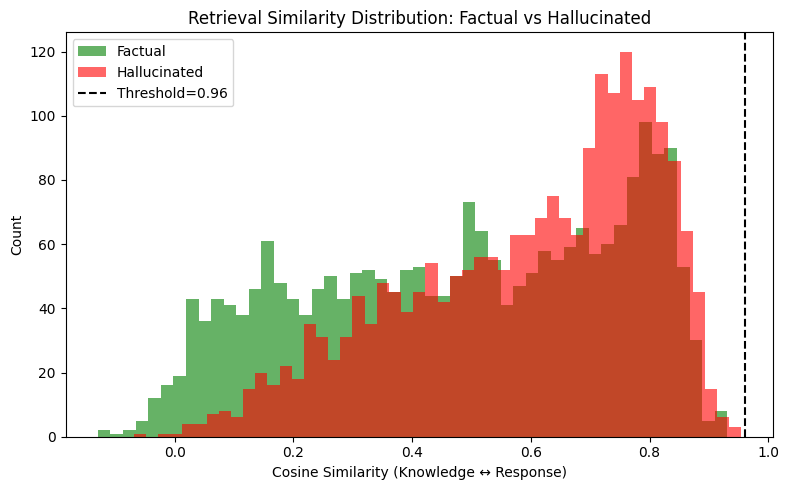

Saved: retrieval_similarity_distribution.png


In [15]:
# Visualization: Similarity distribution by label
plt.figure(figsize=(8, 5))
plt.hist(similarities[test_labels == 0], bins=50, alpha=0.6, label="Factual", color="green")
plt.hist(similarities[test_labels == 1], bins=50, alpha=0.6, label="Hallucinated", color="red")
plt.axvline(x=best_thresh, color="black", linestyle="--", label=f"Threshold={best_thresh:.2f}")
plt.xlabel("Cosine Similarity (Knowledge ↔ Response)")
plt.ylabel("Count")
plt.title("Retrieval Similarity Distribution: Factual vs Hallucinated")
plt.legend()
plt.tight_layout()
plt.savefig("retrieval_similarity_distribution.png", dpi=150)
plt.show()
print("Saved: retrieval_similarity_distribution.png")

---
## 6. Experiment 2: Uncertainty Quantification — Monte Carlo Dropout

**Purpose:** Estimate prediction uncertainty by running multiple forward passes
with dropout enabled. High variance → model is uncertain → likely wrong.

**From proposal Phase 2:** Uncertainty-Aware Detection
**Proposal objective:** L = L_classification + λ * L_calibration

In [18]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model_ft = nn.DataParallel(model_ft)

Using 2 GPUs with DataParallel


In [19]:
print("=" * 60)
print("EXPERIMENT 2: Uncertainty Quantification (MC Dropout)")
print("=" * 60)

def mc_dropout_predict(model, tokenizer, texts, n_samples=20, batch_size=16, max_length=512):
    """
    Monte Carlo Dropout: Run N forward passes with dropout ENABLED.

    Returns:
        mean_probs:   Average P(hallucination) across passes  [n_texts]
        uncertainty:  Std dev across passes (higher = less certain)  [n_texts]
        all_probs:    Raw probabilities from each pass  [n_samples, n_texts]
    """
    model.train()  # CRITICAL: enables dropout at inference

    all_pass_probs = []

    for sample_idx in range(n_samples):
        pass_probs = []

        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i + batch_size]
                inputs = tokenizer(
                    batch_texts, truncation=True, max_length=max_length,
                    padding=True, return_tensors="pt"
                ).to(device)

                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)
                hall_probs = probs[:, 1].cpu().numpy()
                pass_probs.extend(hall_probs.tolist())

        all_pass_probs.append(pass_probs)

        if (sample_idx + 1) % 5 == 0:
            print(f"  MC Dropout pass {sample_idx + 1}/{n_samples} complete")

    all_pass_probs = np.array(all_pass_probs)  # [n_samples, n_texts]
    mean_probs = np.mean(all_pass_probs, axis=0)
    uncertainty = np.std(all_pass_probs, axis=0)

    model.eval()  # Restore eval mode

    return mean_probs, uncertainty, all_pass_probs

EXPERIMENT 2: Uncertainty Quantification (MC Dropout)


In [22]:
print("Running MC Dropout (20 forward passes)...")
mc_mean_probs, mc_uncertainty, mc_all_probs = mc_dropout_predict(
    model_ft, tokenizer_ft, test_texts, n_samples=20, batch_size=256
)

mc_preds = (mc_mean_probs > 0.5).astype(int)

print(f"\nMC Dropout Stats:")
print(f"  Mean uncertainty: {mc_uncertainty.mean():.4f}")
print(f"  Max uncertainty:  {mc_uncertainty.max():.4f}")
print(f"  Min uncertainty:  {mc_uncertainty.min():.4f}")

Running MC Dropout (20 forward passes)...
  MC Dropout pass 5/20 complete
  MC Dropout pass 10/20 complete
  MC Dropout pass 15/20 complete
  MC Dropout pass 20/20 complete

MC Dropout Stats:
  Mean uncertainty: 0.0333
  Max uncertainty:  0.4778
  Min uncertainty:  0.0001


In [23]:
# Compare standard vs MC Dropout predictions
print(f"\n{'='*50}")
print(f"Standard vs MC Dropout Predictions")
print(f"{'='*50}")

# MC Dropout metrics
acc_mc = accuracy_score(test_labels, mc_preds)
p_mc, r_mc, f1_mc, _ = precision_recall_fscore_support(test_labels, mc_preds, average="binary")
auroc_mc = roc_auc_score(test_labels, mc_mean_probs)

print(f"\nStandard (single pass):")
print(f"  Acc: {acc_std:.4f}  P: {p_std:.4f}  R: {r_std:.4f}  F1: {f1_std:.4f}  AUROC: {auroc_std:.4f}")
print(f"\nMC Dropout (20 passes):")
print(f"  Acc: {acc_mc:.4f}  P: {p_mc:.4f}  R: {r_mc:.4f}  F1: {f1_mc:.4f}  AUROC: {auroc_mc:.4f}")


Standard vs MC Dropout Predictions

Standard (single pass):
  Acc: 0.9127  P: 0.8819  R: 0.9505  F1: 0.9149  AUROC: 0.9771

MC Dropout (20 passes):
  Acc: 0.9318  P: 0.9347  R: 0.9267  F1: 0.9307  AUROC: 0.9784


In [24]:
# Uncertainty vs correctness
correct_mask = (mc_preds == test_labels)
incorrect_mask = ~correct_mask

print(f"\n{'='*50}")
print(f"Uncertainty Analysis: Correct vs Incorrect Predictions")
print(f"{'='*50}")
mean_unc_correct = mc_uncertainty[correct_mask].mean()
mean_unc_incorrect = mc_uncertainty[incorrect_mask].mean() if incorrect_mask.sum() > 0 else 0

print(f"Correct predictions:   mean uncertainty = {mean_unc_correct:.4f} ({correct_mask.sum()} samples)")
print(f"Incorrect predictions: mean uncertainty = {mean_unc_incorrect:.4f} ({incorrect_mask.sum()} samples)")
if mean_unc_correct > 0:
    print(f"Ratio (incorrect/correct): {mean_unc_incorrect / mean_unc_correct:.2f}x")


Uncertainty Analysis: Correct vs Incorrect Predictions
Correct predictions:   mean uncertainty = 0.0252 (4193 samples)
Incorrect predictions: mean uncertainty = 0.1446 (307 samples)
Ratio (incorrect/correct): 5.75x


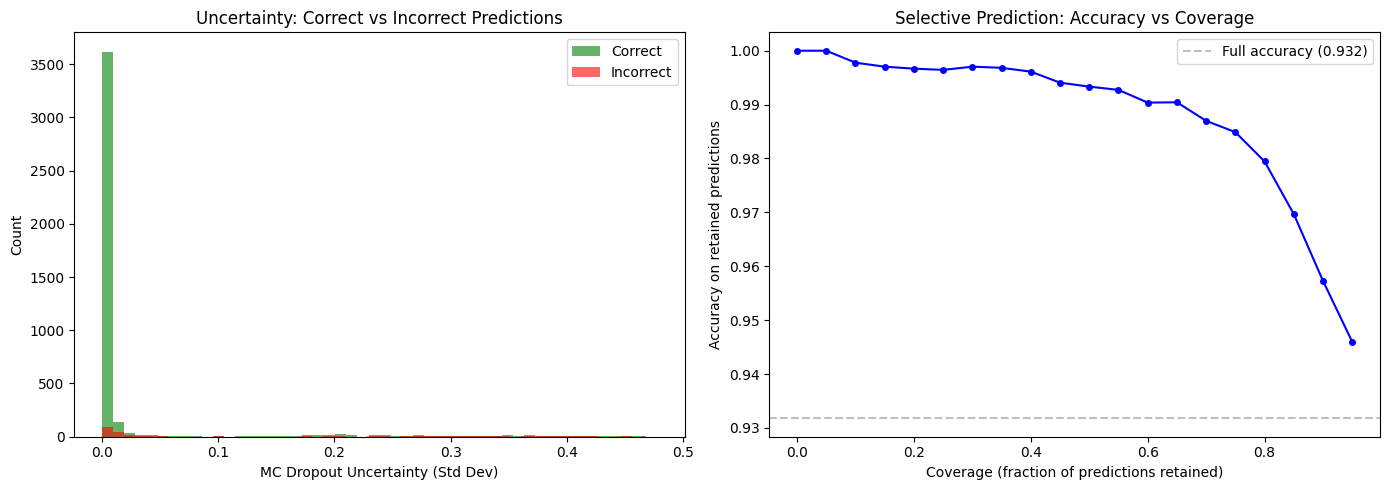

Saved: uncertainty_analysis.png


In [25]:
# Visualization: Uncertainty analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Uncertainty distribution for correct vs incorrect
axes[0].hist(mc_uncertainty[correct_mask], bins=50, alpha=0.6, label="Correct", color="green")
if incorrect_mask.sum() > 0:
    axes[0].hist(mc_uncertainty[incorrect_mask], bins=50, alpha=0.6, label="Incorrect", color="red")
axes[0].set_xlabel("MC Dropout Uncertainty (Std Dev)")
axes[0].set_ylabel("Count")
axes[0].set_title("Uncertainty: Correct vs Incorrect Predictions")
axes[0].legend()

# Plot 2: Selective prediction — accuracy vs coverage
thresholds = np.percentile(mc_uncertainty, np.arange(0, 100, 5))
coverages = []
accuracies = []

for t in thresholds:
    mask = mc_uncertainty <= t
    if mask.sum() > 0:
        coverages.append(mask.mean())
        accuracies.append(accuracy_score(test_labels[mask], mc_preds[mask]))

axes[1].plot(coverages, accuracies, "b-o", markersize=4)
axes[1].set_xlabel("Coverage (fraction of predictions retained)")
axes[1].set_ylabel("Accuracy on retained predictions")
axes[1].set_title("Selective Prediction: Accuracy vs Coverage")
axes[1].axhline(y=acc_mc, color="gray", linestyle="--", alpha=0.5, label=f"Full accuracy ({acc_mc:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("uncertainty_analysis.png", dpi=150)
plt.show()
print("Saved: uncertainty_analysis.png")

---
## 7. Experiment 3: Temperature Scaling (Calibration)

**Purpose:** Improve model confidence calibration so predicted probabilities
better reflect true correctness likelihood.

**From proposal:** L_calibration component of L = L_classification + λ * L_calibration
**Metric:** Expected Calibration Error (ECE)

In [26]:
print("=" * 60)
print("EXPERIMENT 3: Temperature Scaling & Calibration")
print("=" * 60)

def compute_ece(probs, labels, n_bins=15):
    """Compute Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_data = []

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            avg_confidence = probs[in_bin].mean()
            avg_accuracy = labels[in_bin].mean()
            ece += np.abs(avg_accuracy - avg_confidence) * prop_in_bin
            bin_data.append({
                "bin_lower": bin_lower, "bin_upper": bin_upper,
                "avg_confidence": avg_confidence, "avg_accuracy": avg_accuracy,
                "count": in_bin.sum(),
            })

    return ece, bin_data

EXPERIMENT 3: Temperature Scaling & Calibration


In [27]:
# ECE before calibration
pred_confidences = np.where(standard_preds == 1, standard_probs, 1 - standard_probs)
pred_correct = (standard_preds == test_labels).astype(float)
ece_before, bins_before = compute_ece(pred_confidences, pred_correct)
print(f"ECE before temperature scaling: {ece_before:.4f}")

ECE before temperature scaling: 0.0783


In [28]:
# Learn optimal temperature on VALIDATION set
print("\nLearning temperature on validation set...")

val_texts = dataset_splits['validation']['text']
val_labels_list = dataset_splits['validation']['label']

val_logits_list = []
model_ft.eval()
with torch.no_grad():
    for i in range(0, len(val_texts), 64):
        batch = val_texts[i:i+64]
        inputs = tokenizer_ft(
            batch, truncation=True, max_length=512,
            padding=True, return_tensors="pt"
        ).to(device)
        outputs = model_ft(**inputs)
        val_logits_list.append(outputs.logits.cpu())

val_logits = torch.cat(val_logits_list, dim=0)
val_labels_tensor = torch.tensor(val_labels_list)

# Optimize temperature with LBFGS
temperature = nn.Parameter(torch.ones(1) * 1.5)
optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)
nll_criterion = nn.CrossEntropyLoss()

def eval_temp():
    optimizer.zero_grad()
    loss = nll_criterion(val_logits / temperature, val_labels_tensor)
    loss.backward()
    return loss

optimizer.step(eval_temp)
optimal_temp = temperature.item()
print(f"Optimal temperature: {optimal_temp:.4f}")


Learning temperature on validation set...
Optimal temperature: 1.7069


In [29]:
# Apply temperature scaling to test set
print("\nApplying temperature scaling to test set...")

calibrated_probs = torch.softmax(test_logits / optimal_temp, dim=-1)[:, 1].numpy()
calibrated_preds = (calibrated_probs > 0.5).astype(int)

# Calibrated metrics
acc_cal = accuracy_score(test_labels, calibrated_preds)
p_cal, r_cal, f1_cal, _ = precision_recall_fscore_support(test_labels, calibrated_preds, average="binary")
auroc_cal = roc_auc_score(test_labels, calibrated_probs)

# ECE after calibration
cal_confidences = np.where(calibrated_preds == 1, calibrated_probs, 1 - calibrated_probs)
cal_correct = (calibrated_preds == test_labels).astype(float)
ece_after, bins_after = compute_ece(cal_confidences, cal_correct)

print(f"\n{'='*50}")
print(f"Calibration Results")
print(f"{'='*50}")
print(f"ECE before: {ece_before:.4f}")
print(f"ECE after:  {ece_after:.4f}")
print(f"Temperature: {optimal_temp:.4f}")
print(f"\nCalibrated model metrics:")
print(f"  Acc: {acc_cal:.4f}  P: {p_cal:.4f}  R: {r_cal:.4f}  F1: {f1_cal:.4f}  AUROC: {auroc_cal:.4f}")


Applying temperature scaling to test set...

Calibration Results
ECE before: 0.0783
ECE after:  0.0495
Temperature: 1.7069

Calibrated model metrics:
  Acc: 0.9127  P: 0.8819  R: 0.9505  F1: 0.9149  AUROC: 0.9771


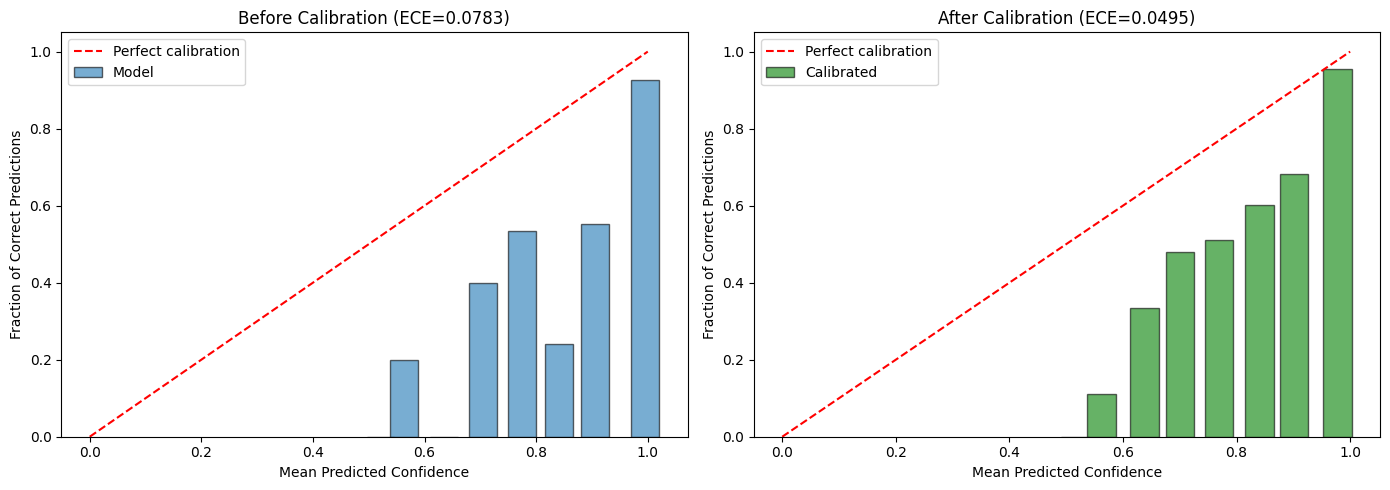

Saved: calibration_reliability_diagram.png


In [30]:
# Reliability diagram (calibration plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
if bins_before:
    bin_confs_before = [b["avg_confidence"] for b in bins_before]
    bin_accs_before = [b["avg_accuracy"] for b in bins_before]
    axes[0].bar(bin_confs_before, bin_accs_before, width=0.05, alpha=0.6, label="Model", edgecolor="black")
axes[0].plot([0, 1], [0, 1], "r--", label="Perfect calibration")
axes[0].set_xlabel("Mean Predicted Confidence")
axes[0].set_ylabel("Fraction of Correct Predictions")
axes[0].set_title(f"Before Calibration (ECE={ece_before:.4f})")
axes[0].legend()

# After calibration
if bins_after:
    bin_confs_after = [b["avg_confidence"] for b in bins_after]
    bin_accs_after = [b["avg_accuracy"] for b in bins_after]
    axes[1].bar(bin_confs_after, bin_accs_after, width=0.05, alpha=0.6, label="Calibrated", edgecolor="black", color="green")
axes[1].plot([0, 1], [0, 1], "r--", label="Perfect calibration")
axes[1].set_xlabel("Mean Predicted Confidence")
axes[1].set_ylabel("Fraction of Correct Predictions")
axes[1].set_title(f"After Calibration (ECE={ece_after:.4f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("calibration_reliability_diagram.png", dpi=150)
plt.show()
print("Saved: calibration_reliability_diagram.png")

---
## 8. Experiment 4: Cross-Dataset Evaluation on SciFact

**Purpose:** Test whether our HaluEval-trained DeBERTa model generalizes to
scientific domain claims WITHOUT additional fine-tuning.

**From proposal Phase 1:** "Will add PubMedBERT retrieval on SciFact corpus"

**SciFact** (Wadden et al., 2020): 1,409 expert-written scientific claims
verified against 5,183 PubMed abstracts. Labels: SUPPORTS, REFUTES, NOT ENOUGH INFO.

**Approach:**
- Load SciFact claims + corpus
- Use PubMedBERT-based sentence-transformer for domain-specific retrieval
- Retrieve top evidence abstract for each claim
- Format as knowledge-claim pair and run through our fine-tuned DeBERTa
- Evaluate: do claims labeled REFUTES get classified as "hallucinated"?

In [33]:
# Load SciFact directly from source (bypasses broken HF loading script)
import json, tarfile, io, requests

print("\nLoading SciFact dataset from source...")
url = "https://scifact.s3-us-west-2.amazonaws.com/release/latest/data.tar.gz"
response = requests.get(url)
tar = tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz")

# Extract corpus
corpus_file = tar.extractfile("data/corpus.jsonl")
scifact_corpus_list = [json.loads(line) for line in corpus_file]
print(f"SciFact corpus: {len(scifact_corpus_list)} abstracts")

# Extract claims (train + dev)
claims_file = tar.extractfile("data/claims_train.jsonl")
scifact_claims_list = [json.loads(line) for line in claims_file]

dev_file = tar.extractfile("data/claims_dev.jsonl")
scifact_claims_list += [json.loads(line) for line in dev_file]
print(f"SciFact claims: {len(scifact_claims_list)} total")


Loading SciFact dataset from source...
SciFact corpus: 5183 abstracts
SciFact claims: 1109 total


In [35]:
pubmed_retriever = SentenceTransformer("pritamdeka/S-PubMedBert-MS-MARCO")
print("Loaded PubMedBERT retriever")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded PubMedBERT retriever


In [37]:
# Build corpus texts
corpus_texts = []
corpus_id_map = {}  # doc_id → index for later lookup

for i, doc in enumerate(scifact_corpus_list):
    title = doc.get('title', '')
    abstract = doc.get('abstract', [])
    if isinstance(abstract, list):
        abstract_text = " ".join(abstract)
    else:
        abstract_text = str(abstract)
    full_text = f"{title}. {abstract_text}" if title else abstract_text
    corpus_texts.append(full_text)
    corpus_id_map[doc['doc_id']] = i

print(f"Corpus size: {len(corpus_texts)} abstracts")
corpus_embeddings = pubmed_retriever.encode(corpus_texts, batch_size=256, show_progress_bar=True)
print(f"Corpus embeddings shape: {corpus_embeddings.shape}")

Corpus size: 5183 abstracts


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Corpus embeddings shape: (5183, 768)


In [39]:
print("\nProcessing SciFact claims...")
scifact_results = []

claim_texts = [c['claim'] for c in scifact_claims_list]
claim_embeddings = pubmed_retriever.encode(claim_texts, batch_size=32, show_progress_bar=True)

for i, claim_data in enumerate(scifact_claims_list):
    claim = claim_data['claim']
    evidence = claim_data.get('evidence', {})

    # Get gold label from evidence
    gold_label = None
    if evidence:
        for doc_id_str, ev_list in evidence.items():
            for ev in ev_list:
                if 'label' in ev:
                    gold_label = ev['label']
                    break
            if gold_label:
                break

    # Retrieve top-1 evidence using PubMedBERT
    sims = util.cos_sim(claim_embeddings[i], corpus_embeddings)[0]
    top_idx = sims.argmax().item()
    top_evidence = corpus_texts[top_idx]
    top_sim = sims[top_idx].item()

    formatted_text = f"Question: {claim}\nKnowledge: {top_evidence[:1500]}\n\nAnswer: {claim}"

    scifact_results.append({
        'claim': claim,
        'gold_label': gold_label,
        'retrieved_evidence': top_evidence[:200],
        'retrieval_sim': top_sim,
        'formatted_text': formatted_text,
    })

print(f"Processed {len(scifact_results)} claims")
print(f"Gold labels found: {sum(1 for r in scifact_results if r['gold_label'] is not None)}")


Processing SciFact claims...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Processed 1109 claims
Gold labels found: 693


In [41]:
# Run DeBERTa on SciFact claims
print("\nClassifying SciFact claims with fine-tuned DeBERTa...")

model_ft.eval()
scifact_texts = [r['formatted_text'] for r in scifact_results]
scifact_deberta_probs = []
scifact_deberta_preds = []

with torch.no_grad():
    for i in range(0, len(scifact_texts), 64):
        batch = scifact_texts[i:i+64]
        inputs = tokenizer_ft(
            batch, truncation=True, max_length=512,
            padding=True, return_tensors="pt"
        ).to(device)
        outputs = model_ft(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        hall_probs = probs[:, 1].cpu().numpy()
        preds = (hall_probs > 0.5).astype(int)
        scifact_deberta_probs.extend(hall_probs.tolist())
        scifact_deberta_preds.extend(preds.tolist())

# Add predictions to results
for i, r in enumerate(scifact_results):
    r['deberta_prob'] = scifact_deberta_probs[i]
    r['deberta_pred'] = scifact_deberta_preds[i]  # 1=hallucinated, 0=factual


Classifying SciFact claims with fine-tuned DeBERTa...


In [42]:
# Evaluate on claims WITH gold labels
print(f"\n{'='*50}")
print(f"SciFact Cross-Dataset Results")
print(f"{'='*50}")

labeled_results = [r for r in scifact_results if r['gold_label'] is not None]
print(f"\nClaims with gold labels: {len(labeled_results)}")

if labeled_results:
    # Map SciFact labels to binary: CONTRADICT → hallucinated (1), SUPPORT → factual (0)
    scifact_true = []
    scifact_pred = []
    scifact_prob = []

    for r in labeled_results:
        if r['gold_label'] in ['CONTRADICT', 'REFUTE', 'REFUTES']:
            scifact_true.append(1)  # Contradicted claim = hallucinated
        elif r['gold_label'] in ['SUPPORT', 'SUPPORTS']:
            scifact_true.append(0)  # Supported claim = factual
        else:
            continue  # Skip ambiguous labels
        scifact_pred.append(r['deberta_pred'])
        scifact_prob.append(r['deberta_prob'])

    if len(scifact_true) > 0:
        scifact_true = np.array(scifact_true)
        scifact_pred = np.array(scifact_pred)
        scifact_prob = np.array(scifact_prob)

        acc_sf = accuracy_score(scifact_true, scifact_pred)
        p_sf, r_sf, f1_sf, _ = precision_recall_fscore_support(
            scifact_true, scifact_pred, average="binary", zero_division=0
        )

        try:
            auroc_sf = roc_auc_score(scifact_true, scifact_prob)
        except ValueError:
            auroc_sf = 0.0

        print(f"\nBinary evaluation (SUPPORT→factual, CONTRADICT→hallucinated):")
        print(f"  Samples:   {len(scifact_true)}")
        print(f"  Accuracy:  {acc_sf:.4f}")
        print(f"  Precision: {p_sf:.4f}")
        print(f"  Recall:    {r_sf:.4f}")
        print(f"  F1 Score:  {f1_sf:.4f}")
        print(f"  AUROC:     {auroc_sf:.4f}")

        # Distribution of predictions
        print(f"\n  Predicted hallucinated: {scifact_pred.sum()} / {len(scifact_pred)}")
        print(f"  Predicted factual:     {len(scifact_pred) - scifact_pred.sum()} / {len(scifact_pred)}")
        print(f"  True hallucinated:     {scifact_true.sum()} / {len(scifact_true)}")
        print(f"  True factual:          {len(scifact_true) - scifact_true.sum()} / {len(scifact_true)}")
    else:
        print("  No mappable gold labels found.")
        acc_sf = p_sf = r_sf = f1_sf = auroc_sf = 0.0
else:
    print("  No labeled claims found in this SciFact version.")
    acc_sf = p_sf = r_sf = f1_sf = auroc_sf = 0.0


SciFact Cross-Dataset Results

Claims with gold labels: 693

Binary evaluation (SUPPORT→factual, CONTRADICT→hallucinated):
  Samples:   693
  Accuracy:  0.3377
  Precision: 0.3382
  Recall:    0.9789
  F1 Score:  0.5027
  AUROC:     0.4009

  Predicted hallucinated: 686 / 693
  Predicted factual:     7 / 693
  True hallucinated:     237 / 693
  True factual:          456 / 693


In [43]:
# Save SciFact results
scifact_df = pd.DataFrame(scifact_results)
scifact_df.to_csv("scifact_cross_dataset_results.csv", index=False)
print("Saved: scifact_cross_dataset_results.csv")

Saved: scifact_cross_dataset_results.csv


---
## 9. Complete Results Summary

In [47]:
print("\n" + "=" * 70)
print("COMPLETE RESULTS SUMMARY — UPDATE 2")
print("=" * 70)

print(f"\n{'Model':<35} {'Acc':>6} {'P':>6} {'R':>6} {'F1':>6} {'AUROC':>6}")
print("-" * 70)
print(f"{'Retrieval Similarity (cosine)':<35} {acc_sim:>6.4f} {p_sim:>6.4f} {r_sim:>6.4f} {f1_sim:>6.4f} {auroc_sim:>6.4f}")
print(f"{'Zero-Shot NLI (from Update 1)':<35} {'0.6007':>6} {'0.7266':>6} {'0.3072':>6} {'0.4319':>6} {'0.6453':>6}")
print(f"{'Fine-Tuned DeBERTa (standard)':<35} {acc_std:>6.4f} {p_std:>6.4f} {r_std:>6.4f} {f1_std:>6.4f} {auroc_std:>6.4f}")
print(f"{'Fine-Tuned DeBERTa (MC Dropout)':<35} {acc_mc:>6.4f} {p_mc:>6.4f} {r_mc:>6.4f} {f1_mc:>6.4f} {auroc_mc:>6.4f}")
print(f"{'Fine-Tuned DeBERTa (Calibrated)':<35} {acc_cal:>6.4f} {p_cal:>6.4f} {r_cal:>6.4f} {f1_cal:>6.4f} {auroc_cal:>6.4f}")


print(f"\n{'='*70}")
print(f"CROSS-DATASET: SciFact (with PubMedBERT retrieval)")
print(f"{'='*70}")
print(f"{'DeBERTa on SciFact':<35} {acc_sf:>6.4f} {p_sf:>6.4f} {r_sf:>6.4f} {f1_sf:>6.4f} {auroc_sf:>6.4f}")

print(f"\n{'='*70}")
print(f"PER-TASK: Retrieval Similarity")
print(f"{'='*70}")
for task, res in retrieval_task_results.items():
    print(f"{task.upper():<18} Acc={res['Acc']:.4f}  P={res['P']:.4f}  R={res['R']:.4f}  F1={res['F1']:.4f}  AUROC={res['AUROC']:.4f}")

print(f"\n{'='*70}")
print(f"CALIBRATION SUMMARY")
print(f"{'='*70}")
print(f"ECE before temperature scaling: {ece_before:.4f}")
print(f"ECE after temperature scaling:  {ece_after:.4f}")
print(f"Optimal temperature:            {optimal_temp:.4f}")
print(f"MC Dropout uncertainty (correct):   {mean_unc_correct:.4f}")
print(f"MC Dropout uncertainty (incorrect): {mean_unc_incorrect:.4f}")


COMPLETE RESULTS SUMMARY — UPDATE 2

Model                                  Acc      P      R     F1  AUROC
----------------------------------------------------------------------
Retrieval Similarity (cosine)       0.4940 0.4940 1.0000 0.6613 0.3794
Zero-Shot NLI (from Update 1)       0.6007 0.7266 0.3072 0.4319 0.6453
Fine-Tuned DeBERTa (standard)       0.9127 0.8819 0.9505 0.9149 0.9771
Fine-Tuned DeBERTa (MC Dropout)     0.9318 0.9347 0.9267 0.9307 0.9784
Fine-Tuned DeBERTa (Calibrated)     0.9127 0.8819 0.9505 0.9149 0.9771

CROSS-DATASET: SciFact (with PubMedBERT retrieval)
DeBERTa on SciFact                  0.3377 0.3382 0.9789 0.5027 0.4009

PER-TASK: Retrieval Similarity
QA                 Acc=0.5239  P=0.5239  R=1.0000  F1=0.6876  AUROC=0.2495
DIALOGUE           Acc=0.4707  P=0.4707  R=1.0000  F1=0.6401  AUROC=0.3303
SUMMARIZATION      Acc=0.4880  P=0.4880  R=1.0000  F1=0.6559  AUROC=0.4700

CALIBRATION SUMMARY
ECE before temperature scaling: 0.0783
ECE after temperature sca

---
## 10. Save All Artifacts

In [45]:
# Save results to CSV
results_summary = pd.DataFrame({
    "Model": [
        "Retrieval Similarity (cosine)",
        "Zero-Shot NLI (DeBERTa-MNLI)",
        "Fine-Tuned DeBERTa (standard)",
        "Fine-Tuned DeBERTa (MC Dropout)",
        "Fine-Tuned DeBERTa (Calibrated)",
        "DeBERTa on SciFact (cross-dataset)",
    ],
    "Accuracy": [acc_sim, 0.6007, acc_std, acc_mc, acc_cal, acc_sf],
    "Precision": [p_sim, 0.7266, p_std, p_mc, p_cal, p_sf],
    "Recall": [r_sim, 0.3072, r_std, r_mc, r_cal, r_sf],
    "F1": [f1_sim, 0.4319, f1_std, f1_mc, f1_cal, f1_sf],
    "AUROC": [auroc_sim, 0.6453, auroc_std, auroc_mc, auroc_cal, auroc_sf],
})
results_summary.to_csv("update2_results_summary.csv", index=False)
print("Saved: update2_results_summary.csv")

# Save per-sample uncertainty data
uncertainty_df = pd.DataFrame({
    "label": test_labels,
    "task": test_tasks,
    "standard_prob": standard_probs,
    "standard_pred": standard_preds,
    "mc_mean_prob": mc_mean_probs,
    "mc_pred": mc_preds,
    "mc_uncertainty": mc_uncertainty,
    "retrieval_similarity": similarities,
    "calibrated_prob": calibrated_probs,
    "calibrated_pred": calibrated_preds,
})
uncertainty_df.to_csv("update2_uncertainty_data.csv", index=False)
print("Saved: update2_uncertainty_data.csv")

Saved: update2_results_summary.csv
Saved: update2_uncertainty_data.csv


In [46]:
print("\n" + "=" * 50)
print("ALL SAVED ARTIFACTS (for GitHub results/update2/)")
print("=" * 50)
print("""
1. retrieval_similarity_distribution.png — Similarity by label
2. uncertainty_analysis.png              — MC Dropout uncertainty
3. calibration_reliability_diagram.png   — Before/after calibration
4. update2_results_summary.csv           — Complete results table
5. update2_uncertainty_data.csv          — Per-sample scores
6. scifact_cross_dataset_results.csv     — SciFact evaluation results
""")


ALL SAVED ARTIFACTS (for GitHub results/update2/)

1. retrieval_similarity_distribution.png — Similarity by label
2. uncertainty_analysis.png              — MC Dropout uncertainty
3. calibration_reliability_diagram.png   — Before/after calibration
4. update2_results_summary.csv           — Complete results table
5. update2_uncertainty_data.csv          — Per-sample scores
6. scifact_cross_dataset_results.csv     — SciFact evaluation results



## 11. Next Steps (for Final Paper)

**Proposal Phase Completion Status:**
- ✅ Phase 1 (Retrieval Grounding): Implemented with all-MiniLM-L6-v2 on HaluEval + PubMedBERT on SciFact
- ✅ Phase 2 (Uncertainty-Aware Detection): MC Dropout + Temperature Scaling / L_calibration
- ⬜ Phase 3 (DPO Fine-tuning): Deferred — "Will explore preference-based learning if time permits"

**Remaining work for Final Paper:**
1. **Integrate TF-IDF baseline** — add HaluEval results to summary table
2. **Context ablation** — performance with/without knowledge
3. **Learning curve** — performance vs training data size
4. **Phase 3 (DPO)** — if time permits, train a DPO model using HaluEval
   hallucinated/factual pairs as preference data; otherwise include in Future Work
5. **Ensemble methods** — combine DeBERTa + retrieval similarity + uncertainty signals
6. **Update paper** — fill in real numbers, update all tables/figures
7. **Final presentation** — 20-minute presentation